In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
dataset = np.loadtxt("knn_dataset_exercicio_3.csv", delimiter=',', skiprows=1)

X_train = dataset[:, :2]

y_train = dataset[:, 2].astype(int)

print("Amostra das carcteristicas (X_train):")
print(X_train[:5])
print("\nAmostra do rótulos (y_train):")
print(y_train[:5])

Amostra das carcteristicas (X_train):
[[ 5.  1.]
 [ 6.  2.]
 [ 8.  2.]
 [10.  3.]
 [12.  4.]]

Amostra do rótulos (y_train):
[1 1 1 1 2]


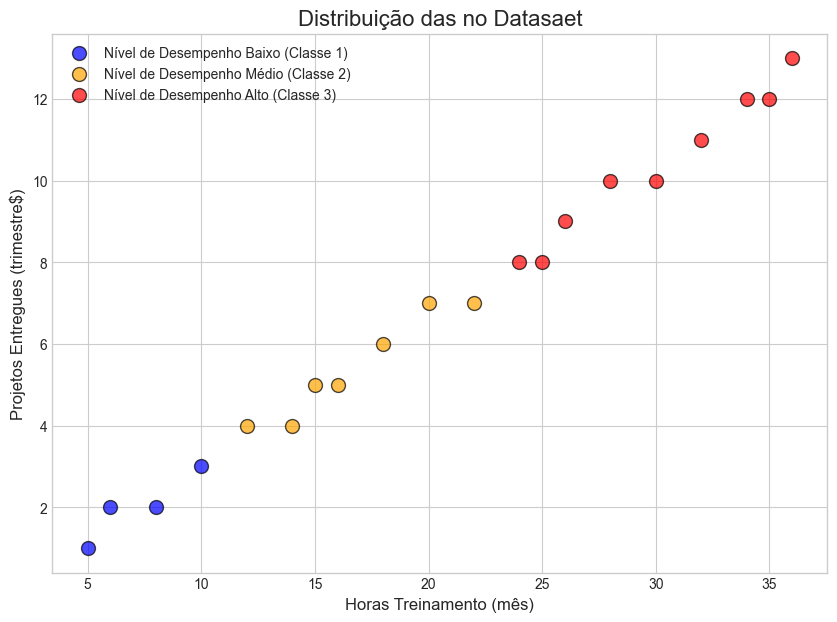

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10,7))

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1,1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Nível de Desempenho Baixo (Classe 1)')

ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Nível de Desempenho Médio (Classe 2)')

ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Nível de Desempenho Alto (Classe 3)')

ax.set_title('Distribuição das no Datasaet', fontsize=16)
ax.set_xlabel('Horas Treinamento (mês)', fontsize=12)
ax.set_ylabel('Projetos Entregues (trimestre$)', fontsize=12)
ax.legend()
plt.show()


In [4]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto teste."""
    
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

        distancias.sort(key=lambda x: x[0])

    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

In [5]:
def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto marjoritário dos vizinhos"""

    contagem_votos = Counter(vizinhos)
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

novo_nivel = np.array([20, 3])
k = 5

vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_nivel, k)
previsao_final = prever_classificacao(vizinhos_proximos)

if previsao_final == 1:
    resultado_texto = "Desempenho Baixo"
elif previsao_final == 2:
    resultado_texto = "Desempenho Médio"
else:
    resultado_texto = "Desempenho Alto"

print(f"O novo nível tem as caracteristicas: {novo_nivel}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-------------------------------------------------------")
print(f"--> Previsão final: O novo nível é classificado como {resultado_texto} (Classe {previsao_final})")


O novo nível tem as caracteristicas: [20  3]
O valor de 'k' escolhido foi: 5
As classes dos vizinhos mais próximos são: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]
-------------------------------------------------------
--> Previsão final: O novo nível é classificado como Desempenho Médio (Classe 2)


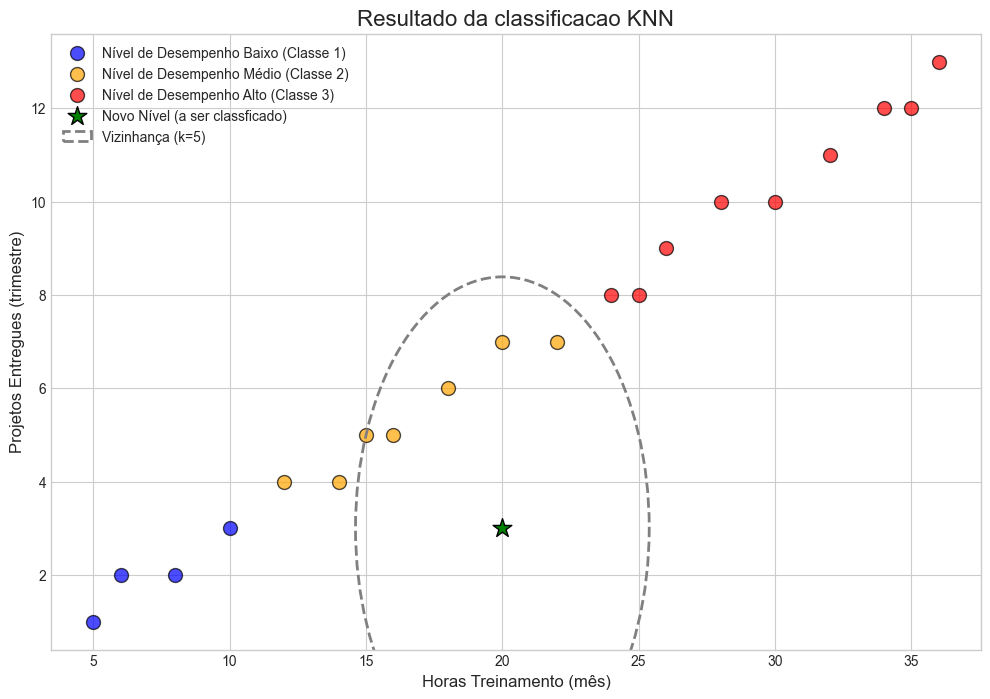

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1,1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Nível de Desempenho Baixo (Classe 1)')

ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Nível de Desempenho Médio (Classe 2)')

ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Nível de Desempenho Alto (Classe 3)')

ax.scatter(novo_nivel[0], novo_nivel[1], c='green', s=200,
           edgecolor='k', marker='*', label='Novo Nível (a ser classficado)')

indice_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_nivel) for p in X_train]) [:k]
pontos_vizinhos = X_train[indice_vizinhos]

distancia_maxima = calcular_distancia_euclidiana(novo_nivel, pontos_vizinhos[-1])
circulo = plt.Circle(novo_nivel, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

ax.set_title('Resultado da classificacao KNN', fontsize=16)
ax.set_xlabel('Horas Treinamento (mês)', fontsize=12)
ax.set_ylabel('Projetos Entregues (trimestre)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()

**a) O KNN separou corretamente os funcionários de baixo, médio e alto desempenho com base nos atributos de treinamento e projetos?**

R: Sim, estão bem dividos no gráfico, com o de baixo ficando mais pra esquerda, médio no meio e alto mais pra direita.

**b) Funcionários com muitas horas de treinamento, mas poucos projetos, poderiam ser classificados incorretamente? O que isso sugere sobre a escolha dos atributos?**

R: Pode sim, pois como é baseado nos vizinhos mais próximos, um funcionário com muitas horas, mas poucos projetos entregues, pode acabar sendo classificado como de médio desempenho, já que está mais próximo de funcionários desse grupo em termos de horas de treinamento. Isso sugere que os atributos escolhidos podem não representar completamente o desempenho, e que pode ser necessário ajustar a importância das variáveis ou incluir novos atributos para melhorar a segmentação.

**c) Se um novo funcionário tivesse 20 horas de treinamento e 3 projetos entregues, em qual categoria o KNN provavelmente o colocaria?**

R: Provavelmente seria classificado como de médio desempenho, pois seus vizinhos mais próximos no espaço de atributos pertencem majoritariamente a essa categoria.